In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from collections import Counter
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import math
import re
from collections import Counter

In [ ]:
source_data ='/content/drive/MyDrive/Học máy/Email_cleaned.csv'
df = pd.read_csv(source_data)
df.head(5)

,label,Message
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answer guy know checked rsync manual wo...


**Thuật toán Naive Bayes**

In [ ]:
df_5k, _ = train_test_split(
    df,
    train_size=5000,
    random_state=42,
    stratify=df["label"]
)
df_5k = df_5k.reset_index(drop=True)
print(df_5k["label"].value_counts())

label
1    2631
0    2369
Name: count, dtype: int64


In [ ]:
X = df_5k["Message"].astype(str)
y = df_5k["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
class MultinomialNB_custom:
    def __init__(self, smoothing=1.0):
        self.vocabulary = set()
        self.word_prob_spam = {}
        self.word_prob_ham = {}
        self.smoothing = smoothing
        self.vocab_size = 0

    def _preprocess(self, text):
        if not isinstance(text, str):
            return []
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        return text.split()

    def fit(self, X, y):
        spam_words = []
        ham_words = []

        for text, label in zip(X, y):
            words = self._preprocess(text)
            self.vocabulary.update(words)

            if label == 1:
                spam_words.extend(words)
            else:
                ham_words.extend(words)

        self.vocab_size = len(self.vocabulary)

        spam_counts = Counter(spam_words)
        ham_counts = Counter(ham_words)

        total_spam_tokens = sum(spam_counts.values())
        total_ham_tokens = sum(ham_counts.values())

        denom_spam = total_spam_tokens + self.smoothing * self.vocab_size
        denom_ham  = total_ham_tokens  + self.smoothing * self.vocab_size

        for word in self.vocabulary:
            self.word_prob_spam[word] = math.log(
                (spam_counts[word] + self.smoothing) / denom_spam
            )

        for word in self.vocabulary:
            self.word_prob_ham[word] = math.log(
                (ham_counts[word] + self.smoothing) / denom_ham
            )

    def predict(self, text):
        words = self._preprocess(text)

        score_spam = 0.0
        score_ham = 0.0

        for word in words:
            if word in self.vocabulary:
                score_spam += self.word_prob_spam[word]
                score_ham  += self.word_prob_ham[word]

        return 1 if score_spam > score_ham else 0


**Ứng dụng thuật toán**

In [ ]:
print("Số mẫu Train:", len(X_train))
print("Số mẫu Test:", len(X_test))

Số mẫu Train: 4000
Số mẫu Test: 1000


In [ ]:
smoothing_values = [1, 0.01, 5]

results = []
predictions_by_smoothing = {}

for s in smoothing_values:
    print(f"\n===== Smoothing = {s} =====")

    model = MultinomialNB_custom(smoothing=s)
    model.fit(X_train, y_train)

    # Predict tập test
    y_pred = [model.predict(text) for text in X_test]

    predictions_by_smoothing[s] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results.append({
        "smoothing": s,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })



===== Smoothing = 1 =====
Accuracy : 0.9360
Precision: 0.9873
Recall   : 0.8897
F1-score : 0.9360

===== Smoothing = 0.01 =====
Accuracy : 0.9380
Precision: 0.9793
Recall   : 0.9011
F1-score : 0.9386

===== Smoothing = 5 =====
Accuracy : 0.9050
Precision: 0.9954
Recall   : 0.8232
F1-score : 0.9011


In [ ]:
best_result = max(results, key=lambda x: x["f1"])
best_smoothing = best_result["smoothing"]

print("Best smoothing:", best_smoothing)
print("Best result:", best_result)



Best smoothing: 0.01
Best result: {'smoothing': 0.01, 'accuracy': 0.938, 'precision': 0.9793388429752066, 'recall': 0.9011406844106464, 'f1': 0.9386138613861386}


In [ ]:
y_pred_best = predictions_by_smoothing[best_smoothing]


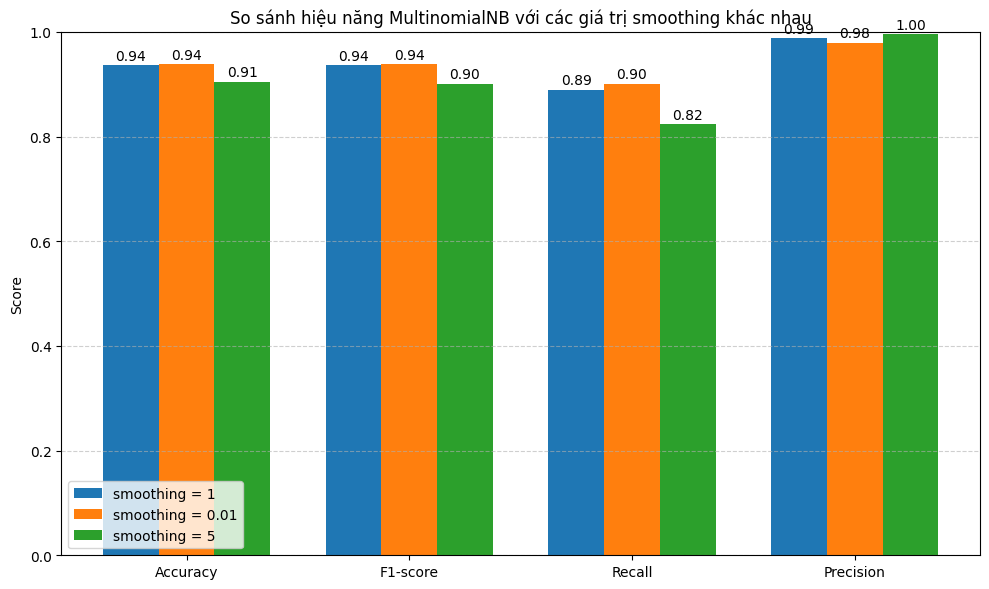

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["accuracy", "f1", "recall", "precision"]
metric_names = ["Accuracy", "F1-score", "Recall", "Precision"]

alphas = [r["smoothing"] for r in results]
values = {r["smoothing"]: [r[m] for m in metrics] for r in results}

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

for i, alpha in enumerate(alphas):
    plt.bar(x + i * width, values[alpha], width, label=f"smoothing = {alpha}")
    for j, v in enumerate(values[alpha]):
        plt.text(x[j] + i * width, v + 0.01, f"{v:.2f}", ha="center")

plt.xticks(x + width, metric_names)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("So sánh hiệu năng MultinomialNB với các giá trị smoothing khác nhau")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


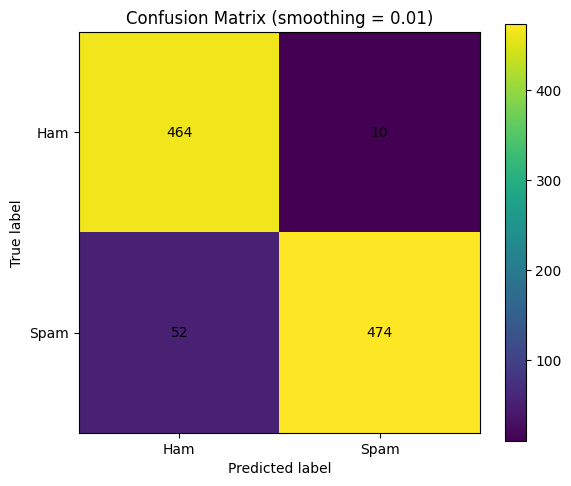

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix (smoothing = {best_smoothing})")
plt.colorbar()

classes = ["Ham", "Spam"]
ticks = np.arange(len(classes))
plt.xticks(ticks, classes)
plt.yticks(ticks, classes)

plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()



In [ ]:
import os
import pickle
import re
import math
from collections import Counter

best_model = MultinomialNB_custom(smoothing=best_smoothing)
best_model.fit(X_train, y_train)


y_pred = [best_model.predict(text) for text in X_test]

y_pred_array = np.array(y_pred)


save_folder = '/content/drive/MyDrive/Học máy/'

if not os.path.exists(save_folder):
    print(f"Cảnh báo: Thư mục '{save_folder}' không tồn tại. Hãy kiểm tra lại việc Mount Drive.")
else:
    file_path = os.path.join(save_folder, "y_pred_mnb.pkl")

    with open(file_path, "wb") as f:
        pickle.dump(y_pred_array, f)


